In [3]:
# ==========================================
# Exploratory Data Analysis (EDA)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# ==========================================
# Load processed dataset
# ==========================================

data_path = Path(
    "../data/processed/lahore/lahore_cleaned.csv"
)

lahore_df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", lahore_df.shape)

Dataset loaded successfully.
Shape: (22632, 15)


In [6]:
# ==========================================
# Convert datetime
# ==========================================

lahore_df["datetime"] = pd.to_datetime(
    lahore_df["datetime"],
    errors="coerce"
)

print("Datetime dtype:")
print(lahore_df["datetime"].dtype)

Datetime dtype:
datetime64[us]


In [7]:
# ==========================================
# Dataset Information
# ==========================================

print("Number of rows:", len(lahore_df))
print("Number of columns:", len(lahore_df.columns))

print("\nColumns:")
print(lahore_df.columns.tolist())

Number of rows: 22632
Number of columns: 15

Columns:
['datetime', 'temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'precipitation', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'us_aqi']


In [8]:
# ==========================================
# Data Types
# ==========================================

print(lahore_df.dtypes)

datetime                datetime64[us]
temperature_2m                 float64
relative_humidity_2m           float64
surface_pressure               float64
precipitation                  float64
cloud_cover                    float64
wind_speed_10m                 float64
wind_direction_10m             float64
pm2_5                          float64
pm10                           float64
carbon_monoxide                float64
nitrogen_dioxide               float64
sulphur_dioxide                float64
ozone                          float64
us_aqi                         float64
dtype: object


In [9]:
# ==========================================
# First 5 rows
# ==========================================

display(lahore_df.head())

,datetime,temperature_2m,relative_humidity_2m,surface_pressure,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
0,2024-01-01 00:00:00,6.15,98.969955,992.69460,0.0,100.0,3.415260,161.56496,260.8,375.3,4925.0,154.8,51.5,11.0,272.10837
1,2024-01-01 01:00:00,6.05,98.287130,992.58790,0.0,100.0,2.276840,161.56496,260.8,375.3,4687.0,147.0,41.1,6.0,272.72916
2,2024-01-01 02:00:00,6.35,98.971620,992.61633,0.0,100.0,2.189795,260.53775,239.3,344.6,4326.0,132.2,32.1,8.0,273.39163
3,2024-01-01 03:00:00,6.15,99.655600,992.69460,0.0,100.0,3.096837,305.53775,208.6,299.0,3733.0,103.5,26.4,24.0,273.42917
4,2024-01-01 04:00:00,6.55,97.282684,992.53800,0.0,100.0,3.096837,305.53775,196.0,281.3,3016.0,67.8,22.2,48.0,273.07916


In [10]:
# ==========================================
# Last 5 rows
# ==========================================

display(lahore_df.tail())

,datetime,temperature_2m,relative_humidity_2m,surface_pressure,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
22627,2026-07-31 19:00:00,29.35,84.93094,974.44470,0.0,100.0,9.292255,58.46526,38.5,38.8,817.0,37.1,9.6,79.0,154.655610
22628,2026-07-31 20:00:00,29.15,86.17158,975.01416,0.0,100.0,9.165871,70.49747,39.1,39.3,888.0,44.1,10.2,54.0,135.374150
22629,2026-07-31 21:00:00,28.85,86.90906,975.57540,0.0,98.0,9.001800,78.46541,38.0,38.2,858.0,43.4,10.3,45.0,114.354170
22630,2026-07-31 22:00:00,28.40,86.61174,976.02690,0.0,88.0,7.922045,88.69808,37.8,38.2,773.0,38.8,10.3,43.0,111.322914
22631,2026-07-31 23:00:00,28.00,87.60826,976.09220,0.0,73.0,8.731392,81.70294,38.5,39.0,683.0,35.2,10.1,41.0,109.031250


In [11]:
# ==========================================
# Missing Values
# ==========================================

missing_values = lahore_df.isnull().sum()

print("Missing values by column:")
display(missing_values)

print(
    "\nTotal missing values:",
    missing_values.sum()
)

Missing values by column:


datetime                0
temperature_2m          0
relative_humidity_2m    0
surface_pressure        0
precipitation           0
cloud_cover             0
wind_speed_10m          0
wind_direction_10m      0
pm2_5                   0
pm10                    0
carbon_monoxide         0
nitrogen_dioxide        0
sulphur_dioxide         0
ozone                   0
us_aqi                  0
dtype: int64


Total missing values: 0


In [12]:
# ==========================================
# Duplicate Rows
# ==========================================

duplicate_rows = lahore_df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [13]:
# ==========================================
# Duplicate Timestamps
# ==========================================

duplicate_timestamps = (
    lahore_df["datetime"].duplicated().sum()
)

print("Duplicate timestamps:", duplicate_timestamps)

Duplicate timestamps: 0


In [14]:
# ==========================================
# Date Range
# ==========================================

print("Minimum datetime:")
print(lahore_df["datetime"].min())

print("\nMaximum datetime:")
print(lahore_df["datetime"].max())

Minimum datetime:
2024-01-01 00:00:00

Maximum datetime:
2026-07-31 23:00:00


In [15]:
# ==========================================
# Check Hourly Continuity
# ==========================================

lahore_df = (
    lahore_df
    .sort_values("datetime")
    .reset_index(drop=True)
)

time_difference = lahore_df["datetime"].diff()

expected_interval = pd.Timedelta(hours=1)

non_hourly_gaps = time_difference[
    time_difference.notna() &
    (time_difference != expected_interval)
]

print(
    "Number of non-hourly gaps:",
    len(non_hourly_gaps)
)

Number of non-hourly gaps: 0


In [16]:
# ==========================================
# Descriptive Statistics
# ==========================================

lahore_df.describe()

,datetime,temperature_2m,relative_humidity_2m,surface_pressure,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
count,22632,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000,22632.000000
mean,2025-04-16 11:30:00,24.108994,62.801506,983.159531,0.089060,32.055320,6.559402,180.096337,68.301697,100.604339,1269.717038,38.739550,15.887641,90.933634,151.115624
min,2024-01-01 00:00:00,2.700000,5.313913,965.638500,0.000000,0.000000,0.000000,0.818439,3.400000,3.600000,153.000000,0.000000,0.100000,0.000000,56.139935
25%,2024-08-23 17:45:00,17.350000,44.380607,977.250450,0.000000,0.000000,3.758510,87.137660,34.200000,52.200000,492.000000,12.700000,9.600000,38.000000,112.049485
50%,2025-04-16 11:30:00,25.650000,65.919690,983.223985,0.000000,6.000000,5.904439,152.271080,51.900000,78.700000,823.000000,28.300000,13.000000,75.000000,150.988100
75%,2025-12-08 05:15:00,30.650000,82.636195,989.083343,0.000000,75.000000,8.604301,292.109500,84.300000,126.700000,1649.250000,57.700000,18.900000,142.000000,175.795395
max,2026-07-31 23:00:00,46.450000,100.000000,1001.728500,19.900000,100.000000,36.659950,360.000000,365.100000,890.300000,8602.000000,201.900000,94.400000,305.000000,537.537540
std,NaN,8.857348,23.599130,7.024958,0.707838,40.612065,3.953640,109.536411,50.450337,75.164959,1150.900017,33.237382,9.644478,64.009149,50.324198


In [17]:
# ==========================================
# Transposed Descriptive Statistics
# ==========================================

lahore_df.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,22632,2025-04-16 11:30:00,2024-01-01 00:00:00,2024-08-23 17:45:00,2025-04-16 11:30:00,2025-12-08 05:15:00,2026-07-31 23:00:00,NaN
temperature_2m,22632.0,24.108994,2.7,17.35,25.65,30.65,46.45,8.857348
relative_humidity_2m,22632.0,62.801506,5.313913,44.380607,65.91969,82.636195,100.0,23.59913
surface_pressure,22632.0,983.159531,965.6385,977.25045,983.223985,989.083343,1001.7285,7.024958
precipitation,22632.0,0.08906,0.0,0.0,0.0,0.0,19.9,0.707838
cloud_cover,22632.0,32.05532,0.0,0.0,6.0,75.0,100.0,40.612065
wind_speed_10m,22632.0,6.559402,0.0,3.75851,5.904439,8.604301,36.65995,3.95364
wind_direction_10m,22632.0,180.096337,0.818439,87.13766,152.27108,292.1095,360.0,109.536411
pm2_5,22632.0,68.301697,3.4,34.2,51.9,84.3,365.1,50.450337
pm10,22632.0,100.604339,3.6,52.2,78.7,126.7,890.3,75.164959


In [18]:
# ==========================================
# Variable Groups
# ==========================================

weather_columns = [
    "temperature_2m",
    "relative_humidity_2m",
    "surface_pressure",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m"
]

pollutant_columns = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

target_column = "us_aqi"

print("Weather variables:")
print(weather_columns)

print("\nPollutant variables:")
print(pollutant_columns)

print("\nTarget variable:")
print(target_column)

Weather variables:
['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'precipitation', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m']

Pollutant variables:
['pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']

Target variable:
us_aqi


In [19]:
# ==========================================
# AQI Statistics
# ==========================================

aqi = lahore_df["us_aqi"]

print("Minimum AQI:", aqi.min())
print("Maximum AQI:", aqi.max())
print("Mean AQI:", aqi.mean())
print("Median AQI:", aqi.median())
print("Standard deviation:", aqi.std())

Minimum AQI: 56.139935
Maximum AQI: 537.53754
Mean AQI: 151.11562408664722
Median AQI: 150.9881
Standard deviation: 50.32419828190472


In [20]:
# ==========================================
# AQI Percentiles
# ==========================================

aqi_percentiles = aqi.quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

display(aqi_percentiles)

0.01     70.948266
0.05     83.372646
0.25    112.049485
0.50    150.988100
0.75    175.795395
0.95    242.571881
0.99    296.977731
Name: us_aqi, dtype: float64

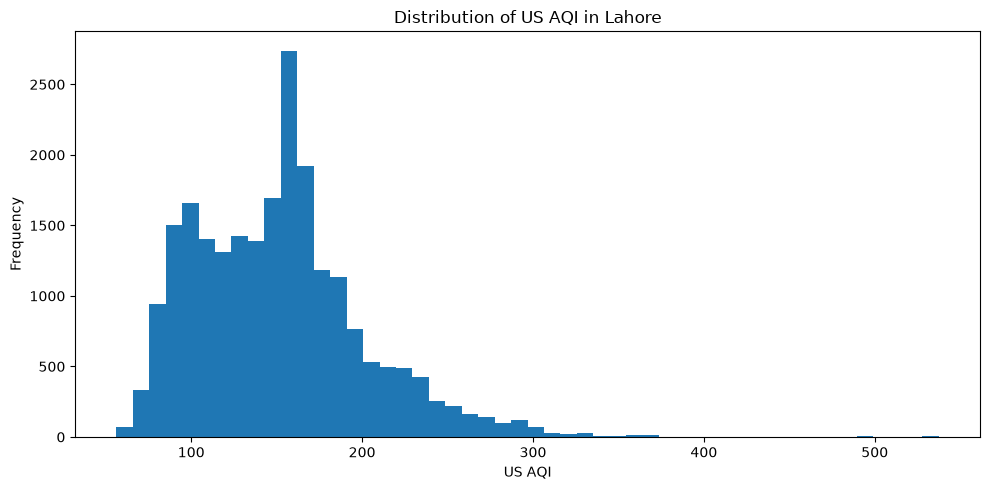

In [21]:
# ==========================================
# AQI Distribution
# ==========================================

plt.figure(figsize=(10, 5))

plt.hist(
    lahore_df["us_aqi"],
    bins=50
)

plt.xlabel("US AQI")
plt.ylabel("Frequency")
plt.title("Distribution of US AQI in Lahore")

plt.tight_layout()
plt.show()

C:\Users\mtalh\AppData\Local\Temp\ipykernel_18720\2812335817.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


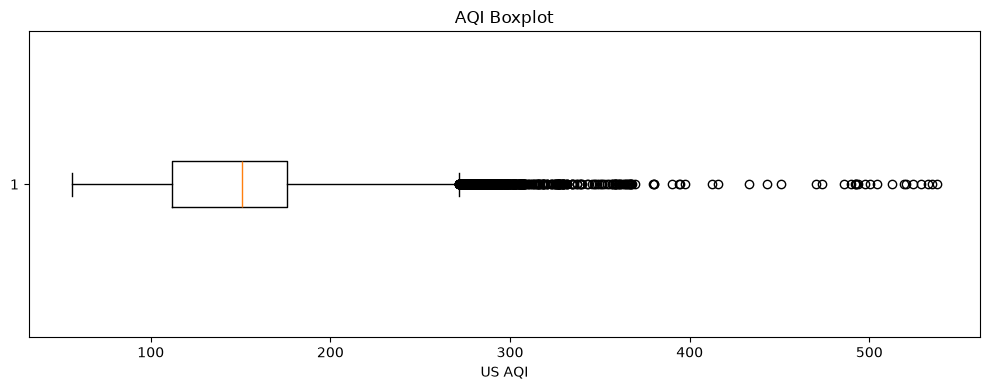

In [22]:
# ==========================================
# AQI Boxplot
# ==========================================

plt.figure(figsize=(10, 4))

plt.boxplot(
    lahore_df["us_aqi"],
    vert=False
)

plt.xlabel("US AQI")
plt.title("AQI Boxplot")

plt.tight_layout()
plt.show()

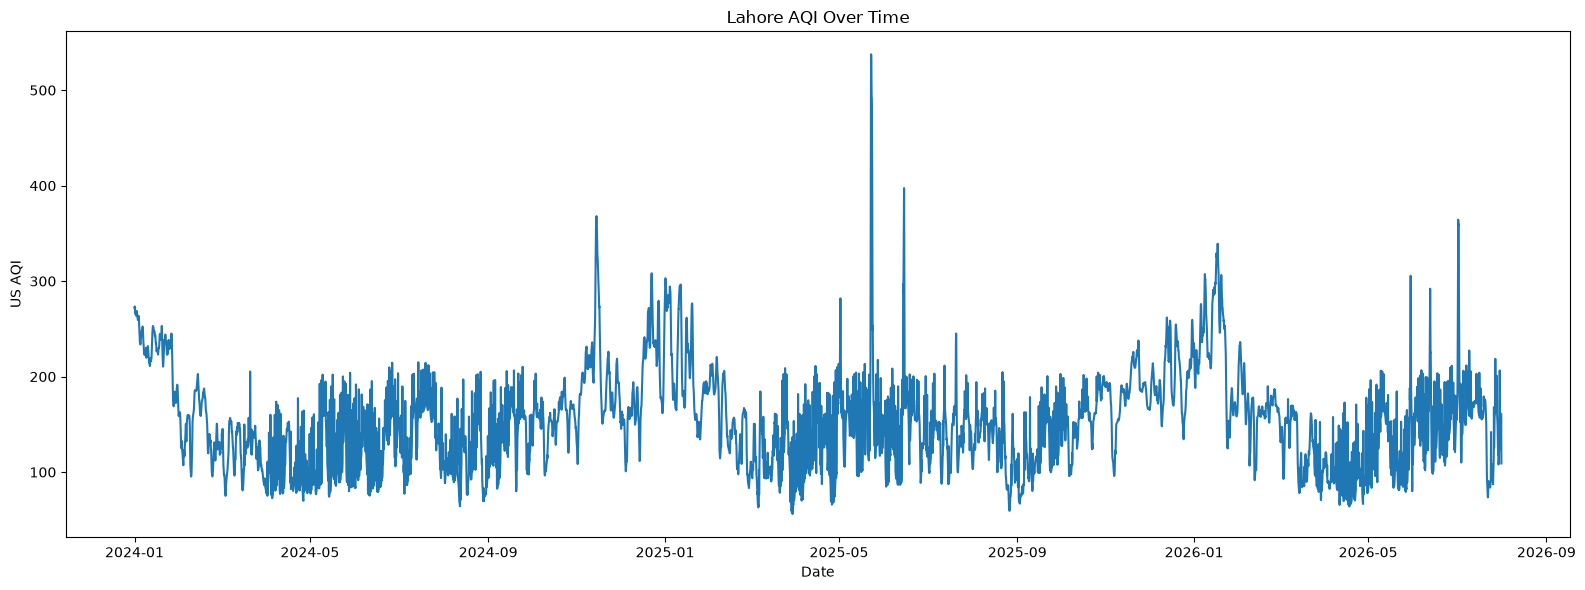

In [23]:
# ==========================================
# AQI Time Series
# ==========================================

plt.figure(figsize=(16, 6))

plt.plot(
    lahore_df["datetime"],
    lahore_df["us_aqi"]
)

plt.xlabel("Date")
plt.ylabel("US AQI")
plt.title("Lahore AQI Over Time")

plt.tight_layout()
plt.show()

In [24]:
# ==========================================
# Create temporary time features for EDA
# ==========================================

lahore_df["year"] = lahore_df["datetime"].dt.year
lahore_df["month"] = lahore_df["datetime"].dt.month
lahore_df["hour"] = lahore_df["datetime"].dt.hour
lahore_df["day_of_week"] = lahore_df["datetime"].dt.dayofweek

print("Temporary EDA time features created.")

Temporary EDA time features created.


In [25]:
# ==========================================
# Monthly AQI
# ==========================================

monthly_aqi = (
    lahore_df
    .groupby("month")["us_aqi"]
    .agg(
        mean="mean",
        median="median",
        maximum="max",
        minimum="min"
    )
)

display(monthly_aqi)

,mean,median,maximum,minimum
month,,,,
1,222.290949,225.014605,339.20837,124.802086
2,155.020074,159.154765,236.18335,83.246860
3,118.859357,117.770840,208.83460,56.139935
4,106.880802,97.351745,213.39957,63.970123
5,138.108301,134.760420,537.53754,74.174530
6,141.931071,142.281250,397.38020,75.314460
7,147.895523,152.965775,364.27094,73.529880
8,120.592607,116.879250,205.07516,59.433960
9,128.856753,126.604163,210.24438,66.996860


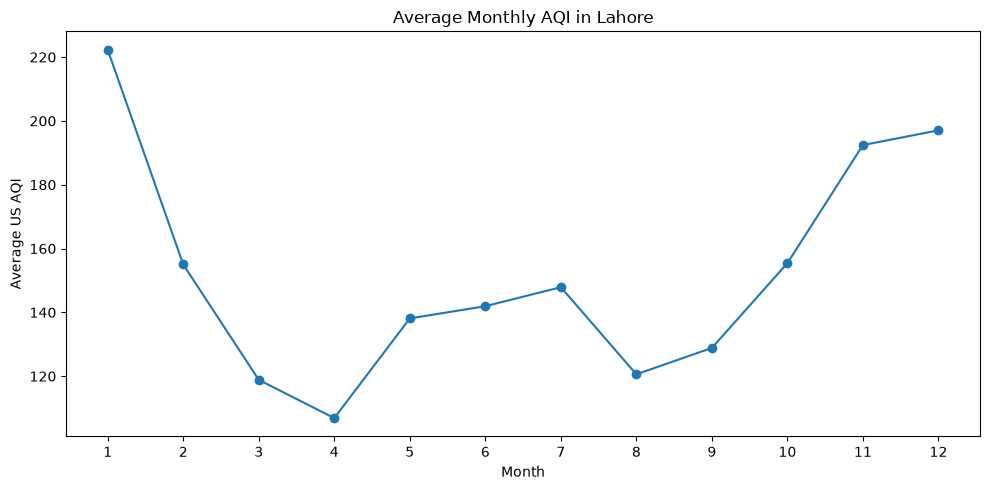

In [26]:
# ==========================================
# Monthly Average AQI
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_aqi.index,
    monthly_aqi["mean"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average US AQI")
plt.title("Average Monthly AQI in Lahore")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [27]:
# ==========================================
# Yearly AQI Statistics
# ==========================================

yearly_aqi = (
    lahore_df
    .groupby("year")["us_aqi"]
    .agg(
        mean="mean",
        median="median",
        maximum="max",
        minimum="min"
    )
)

display(yearly_aqi)

,mean,median,maximum,minimum
year,,,,
2024,149.252544,147.927070,368.00415,64.182396
2025,153.463798,151.818455,537.53754,56.139935
2026,150.289228,152.497020,364.27094,63.970123


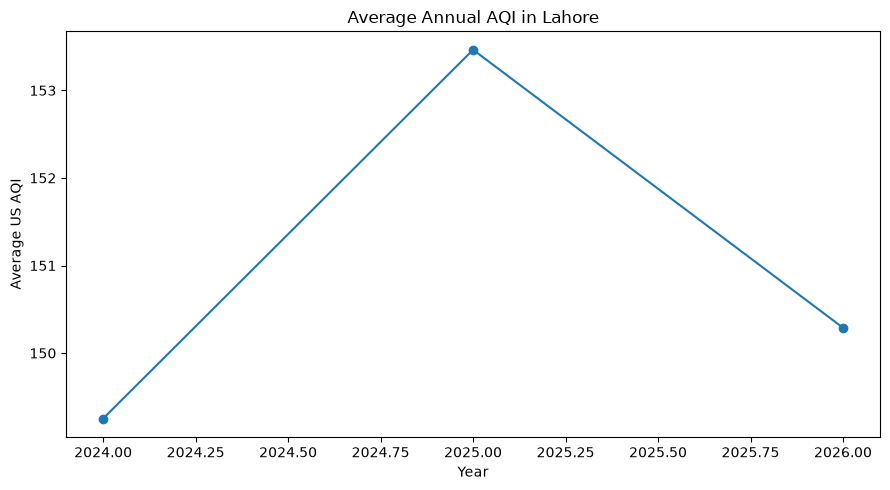

In [28]:
plt.figure(figsize=(9, 5))

plt.plot(
    yearly_aqi.index,
    yearly_aqi["mean"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average US AQI")
plt.title("Average Annual AQI in Lahore")

plt.tight_layout()
plt.show()

In [29]:
# ==========================================
# Average AQI by Hour
# ==========================================

hourly_aqi = (
    lahore_df
    .groupby("hour")["us_aqi"]
    .agg(
        mean="mean",
        median="median",
        maximum="max"
    )
)

display(hourly_aqi)

,mean,median,maximum
hour,,,
0,146.531332,144.51044,473.76250
1,146.443656,143.65623,500.28748
2,146.417129,143.97919,520.15830
3,146.372457,143.36460,532.72920
4,146.331685,143.78125,537.53754
5,146.312607,143.68748,534.97920
6,146.280969,144.35417,528.77080
7,146.253705,144.05208,524.42500
8,146.214329,144.12502,519.45830


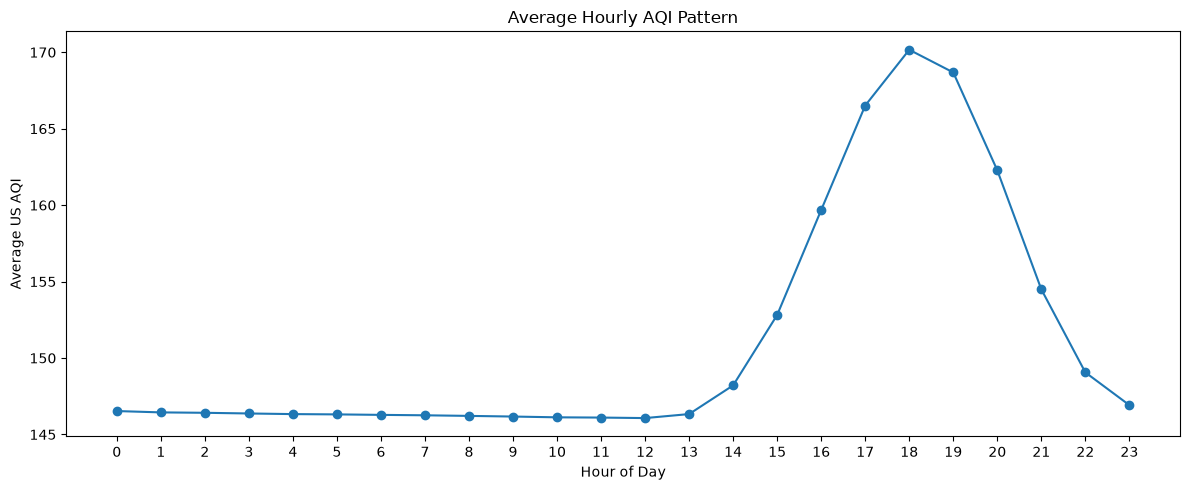

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_aqi.index,
    hourly_aqi["mean"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average US AQI")
plt.title("Average Hourly AQI Pattern")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

In [31]:
# ==========================================
# AQI by Day of Week
# ==========================================

weekday_aqi = (
    lahore_df
    .groupby("day_of_week")["us_aqi"]
    .mean()
)

display(weekday_aqi)

day_of_week
0    152.081819
1    149.642770
2    149.858414
3    150.376469
4    153.002579
5    152.224416
6    150.627500
Name: us_aqi, dtype: float64

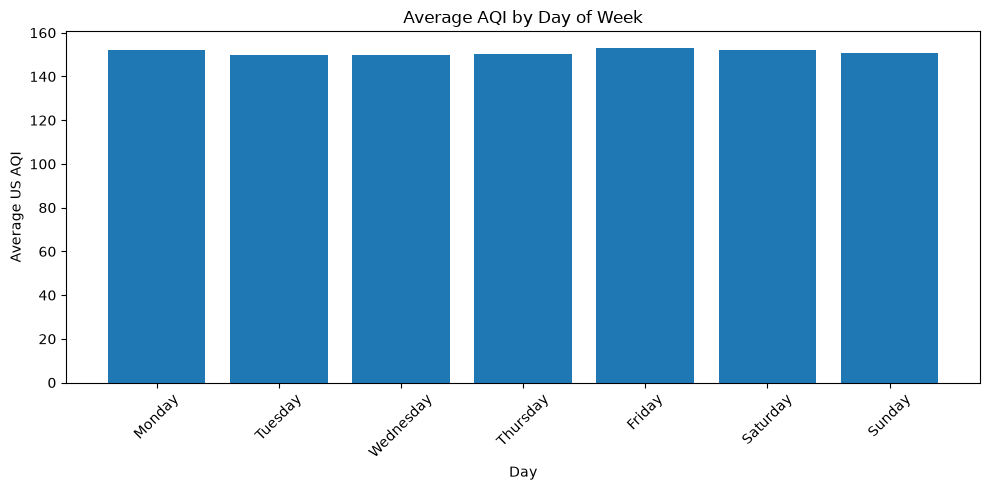

In [32]:
day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10, 5))

plt.bar(
    day_names,
    weekday_aqi.values
)

plt.xlabel("Day")
plt.ylabel("Average US AQI")
plt.title("Average AQI by Day of Week")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
# ==========================================
# Pollutant Descriptive Statistics
# ==========================================

pollutant_stats = (
    lahore_df[pollutant_columns]
    .describe()
    .T
)

display(pollutant_stats)

,count,mean,std,min,25%,50%,75%,max
pm2_5,22632.0,68.301697,50.450337,3.4,34.2,51.9,84.30,365.1
pm10,22632.0,100.604339,75.164959,3.6,52.2,78.7,126.70,890.3
carbon_monoxide,22632.0,1269.717038,1150.900017,153.0,492.0,823.0,1649.25,8602.0
nitrogen_dioxide,22632.0,38.739550,33.237382,0.0,12.7,28.3,57.70,201.9
sulphur_dioxide,22632.0,15.887641,9.644478,0.1,9.6,13.0,18.90,94.4
ozone,22632.0,90.933634,64.009149,0.0,38.0,75.0,142.00,305.0


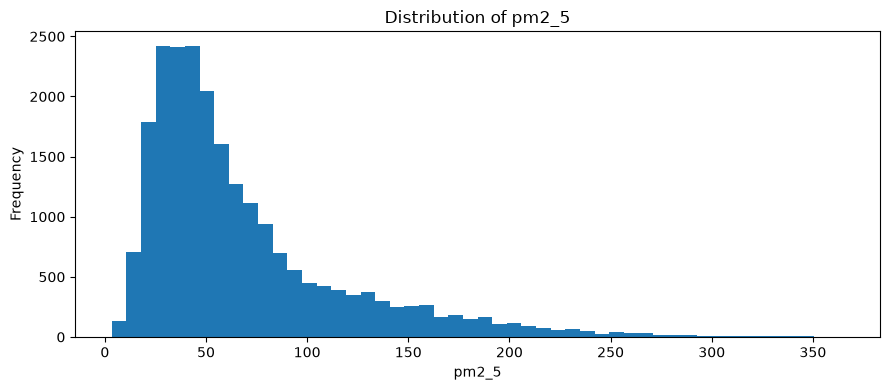

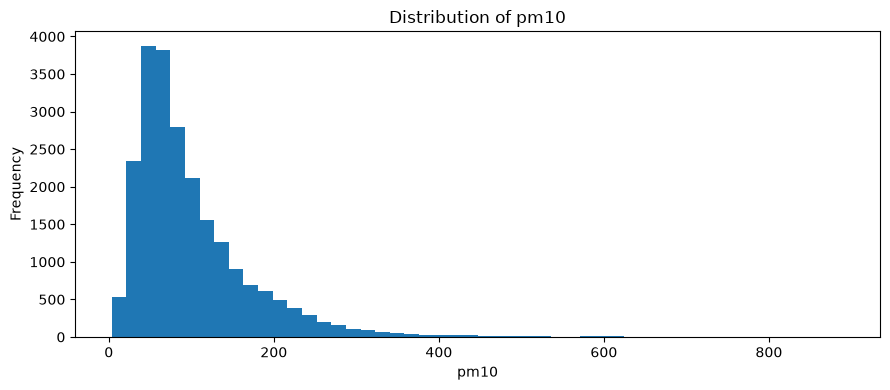

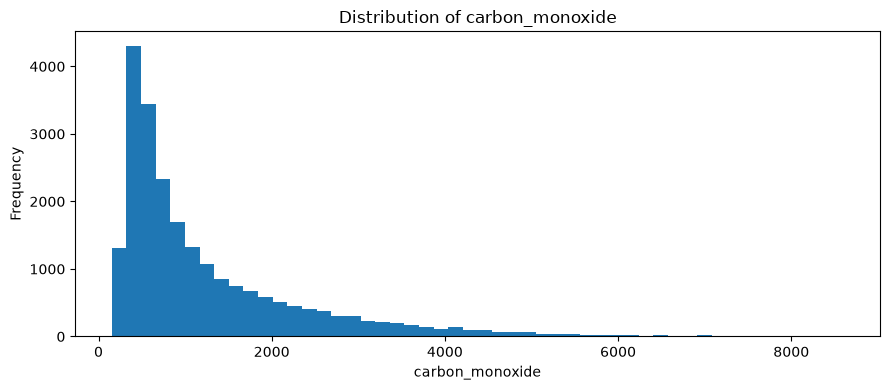

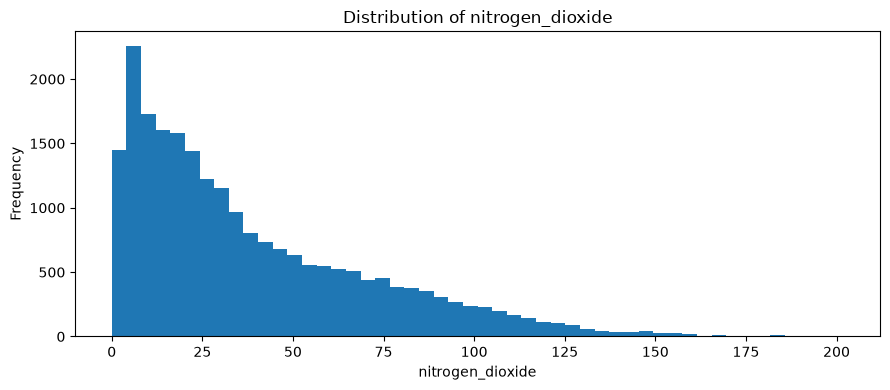

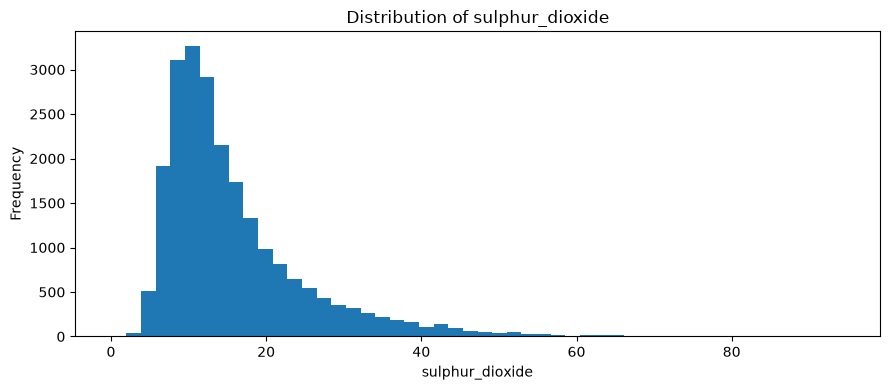

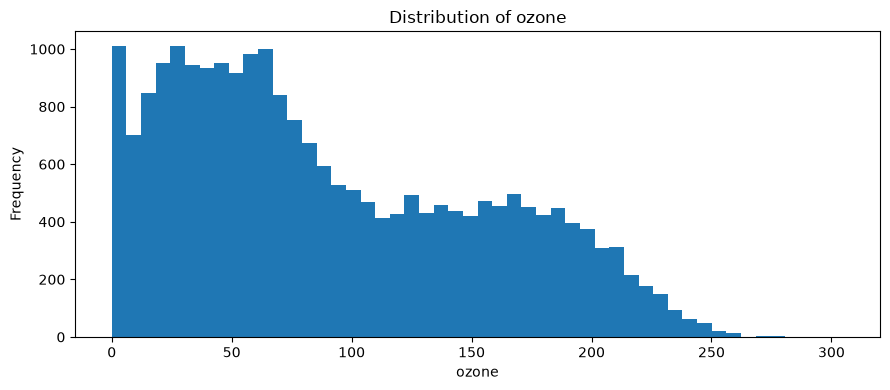

In [34]:
# ==========================================
# Pollutant Distributions
# ==========================================

for column in pollutant_columns:

    plt.figure(figsize=(9, 4))

    plt.hist(
        lahore_df[column],
        bins=50
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}")

    plt.tight_layout()
    plt.show()

C:\Users\mtalh\AppData\Local\Temp\ipykernel_18720\2173723811.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


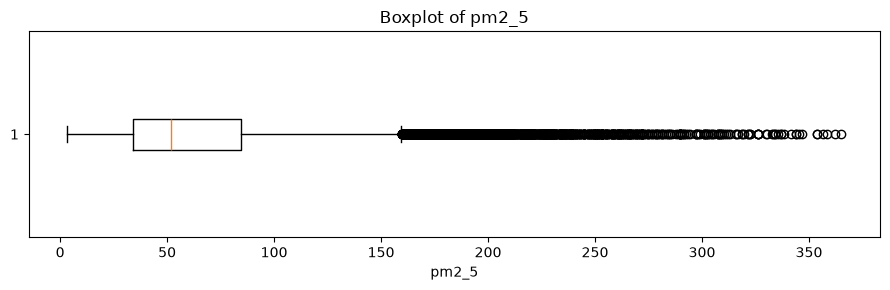

C:\Users\mtalh\AppData\Local\Temp\ipykernel_18720\2173723811.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


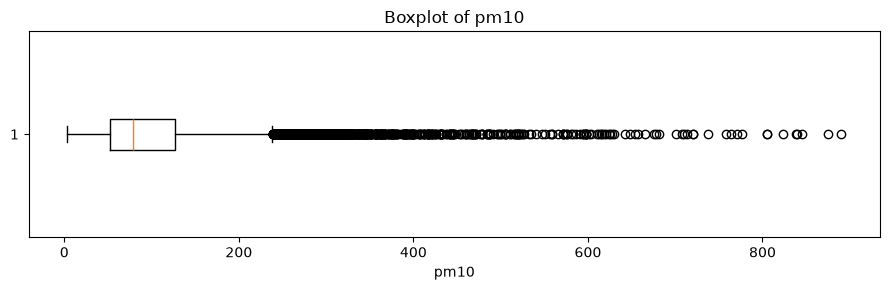

C:\Users\mtalh\AppData\Local\Temp\ipykernel_18720\2173723811.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


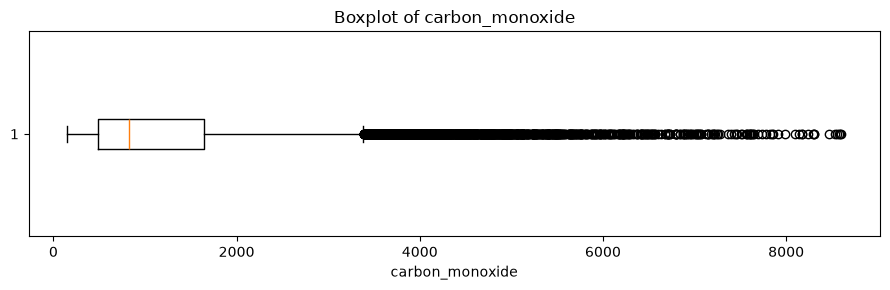

C:\Users\mtalh\AppData\Local\Temp\ipykernel_18720\2173723811.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


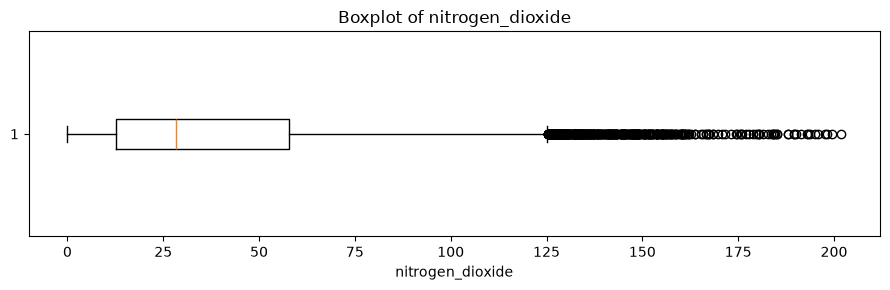

C:\Users\mtalh\AppData\Local\Temp\ipykernel_18720\2173723811.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


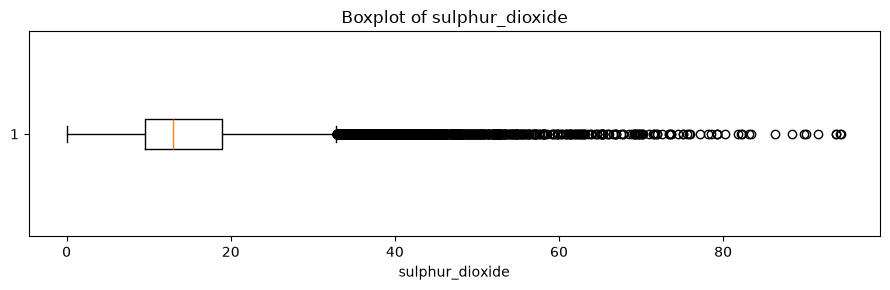

C:\Users\mtalh\AppData\Local\Temp\ipykernel_18720\2173723811.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


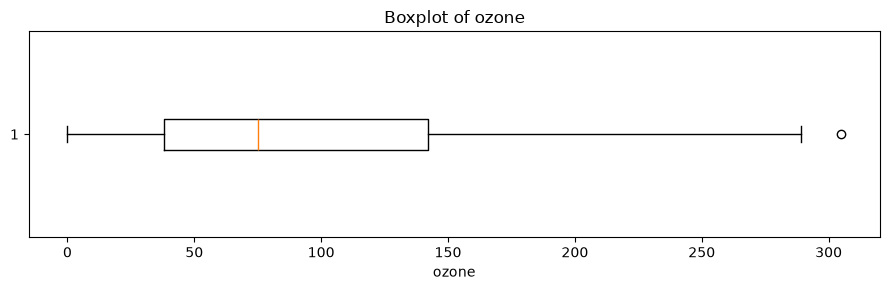

In [35]:
# ==========================================
# Pollutant Boxplots
# ==========================================

for column in pollutant_columns:

    plt.figure(figsize=(9, 3))

    plt.boxplot(
        lahore_df[column],
        vert=False
    )

    plt.xlabel(column)
    plt.title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

In [36]:
# ==========================================
# Weather Descriptive Statistics
# ==========================================

weather_stats = (
    lahore_df[weather_columns]
    .describe()
    .T
)

display(weather_stats)

,count,mean,std,min,25%,50%,75%,max
temperature_2m,22632.0,24.108994,8.857348,2.700000,17.350000,25.650000,30.650000,46.45000
relative_humidity_2m,22632.0,62.801506,23.599130,5.313913,44.380607,65.919690,82.636195,100.00000
surface_pressure,22632.0,983.159531,7.024958,965.638500,977.250450,983.223985,989.083343,1001.72850
precipitation,22632.0,0.089060,0.707838,0.000000,0.000000,0.000000,0.000000,19.90000
cloud_cover,22632.0,32.055320,40.612065,0.000000,0.000000,6.000000,75.000000,100.00000
wind_speed_10m,22632.0,6.559402,3.953640,0.000000,3.758510,5.904439,8.604301,36.65995
wind_direction_10m,22632.0,180.096337,109.536411,0.818439,87.137660,152.271080,292.109500,360.00000


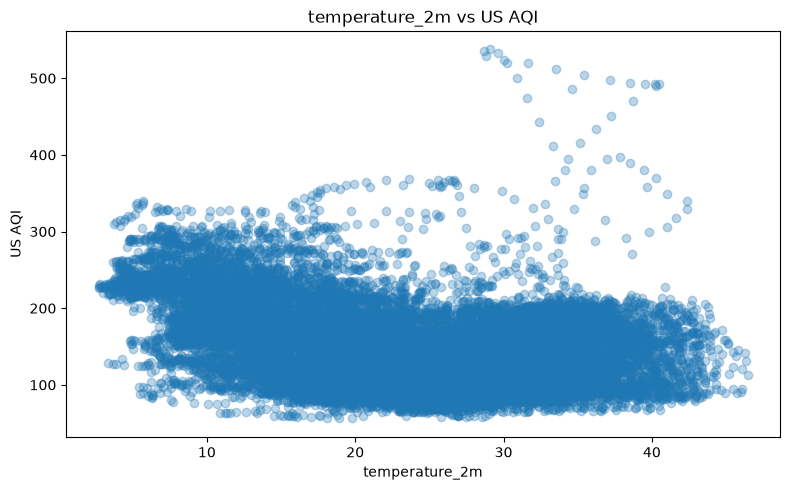

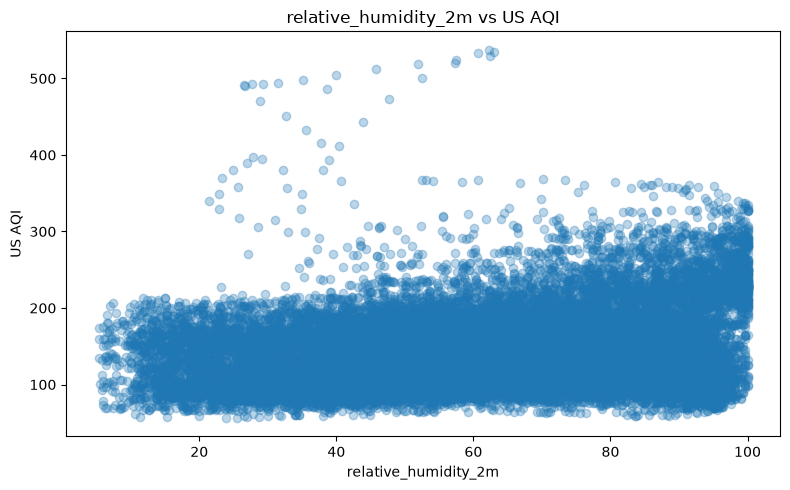

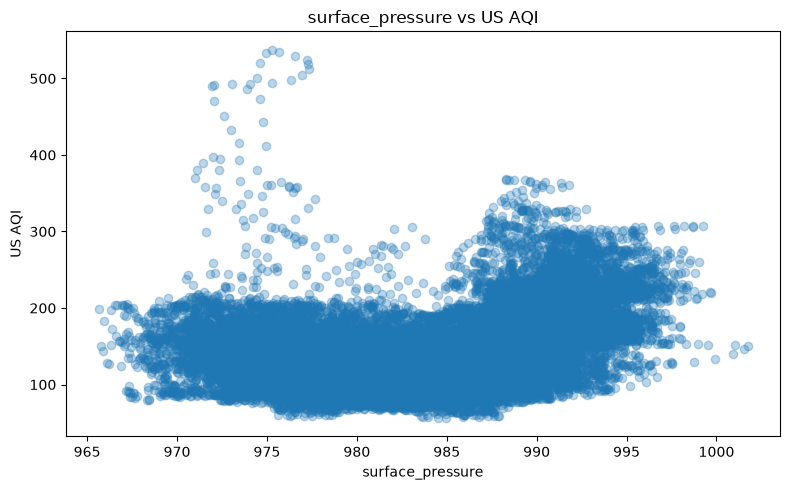

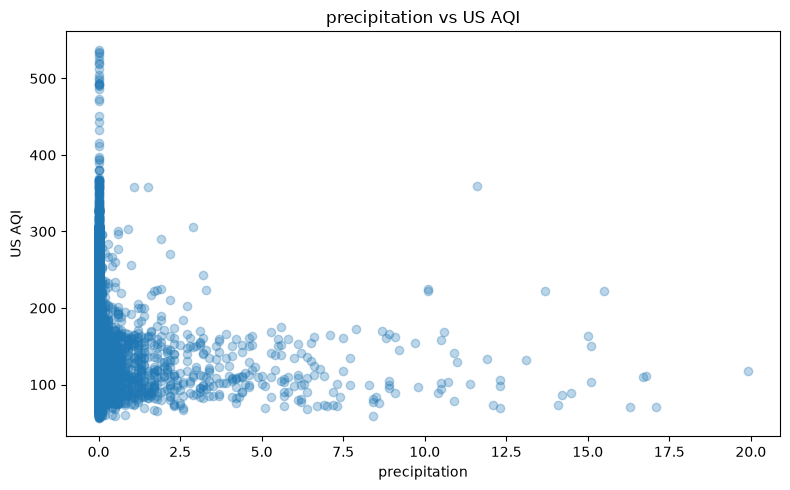

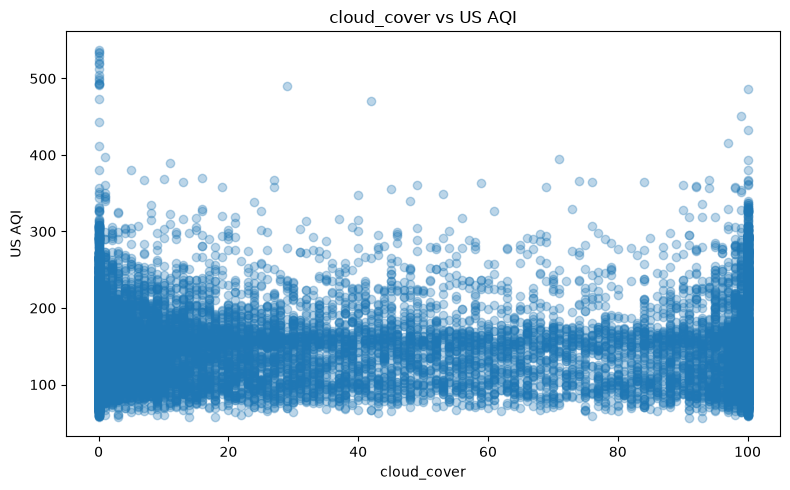

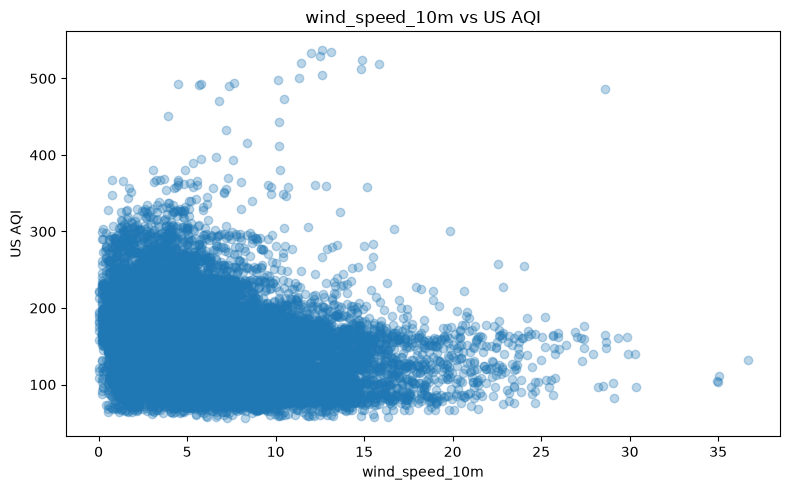

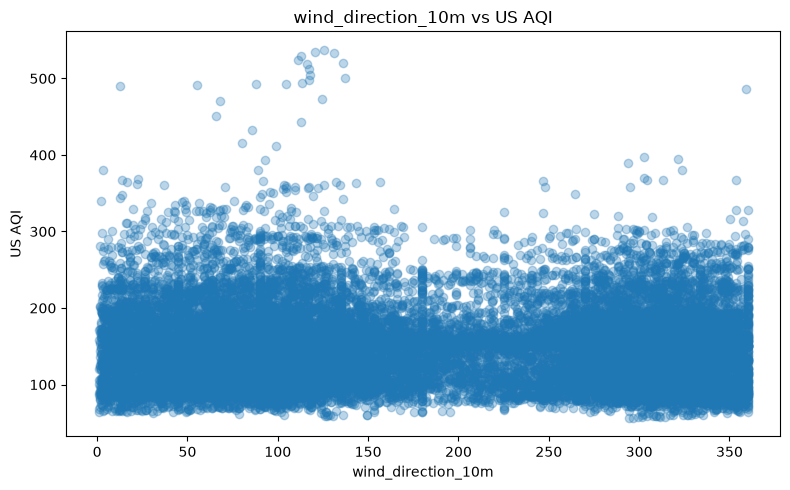

In [37]:
# ==========================================
# Weather Variables vs AQI
# ==========================================

for column in weather_columns:

    plt.figure(figsize=(8, 5))

    plt.scatter(
        lahore_df[column],
        lahore_df["us_aqi"],
        alpha=0.3
    )

    plt.xlabel(column)
    plt.ylabel("US AQI")
    plt.title(f"{column} vs US AQI")

    plt.tight_layout()
    plt.show()

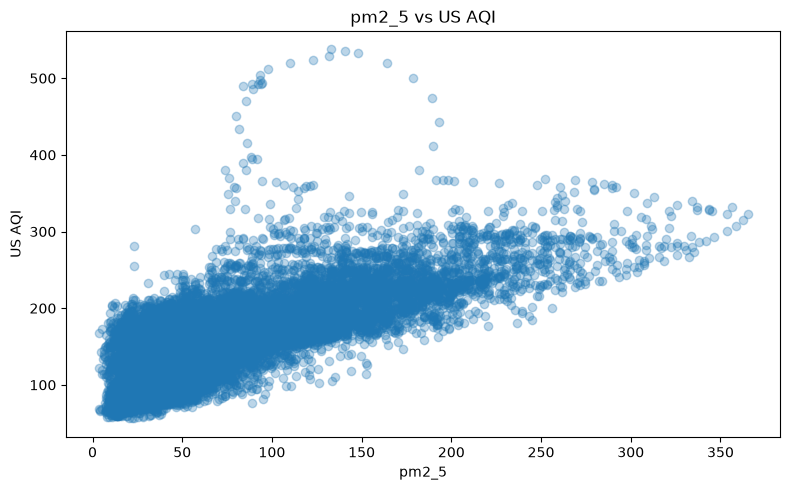

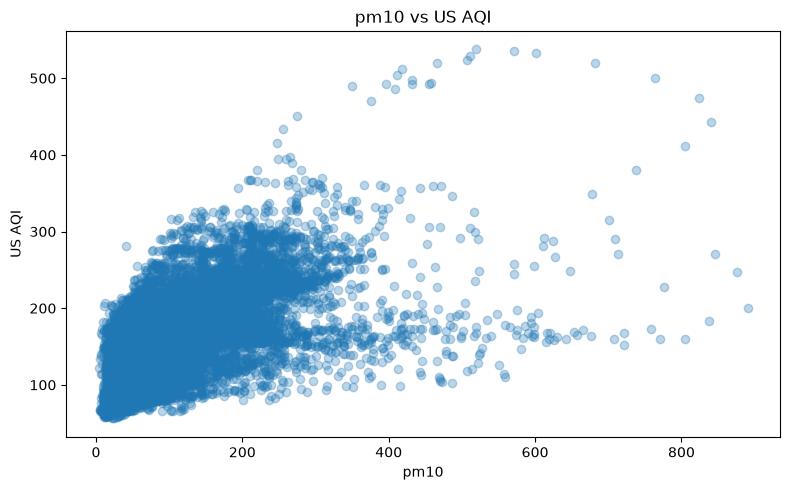

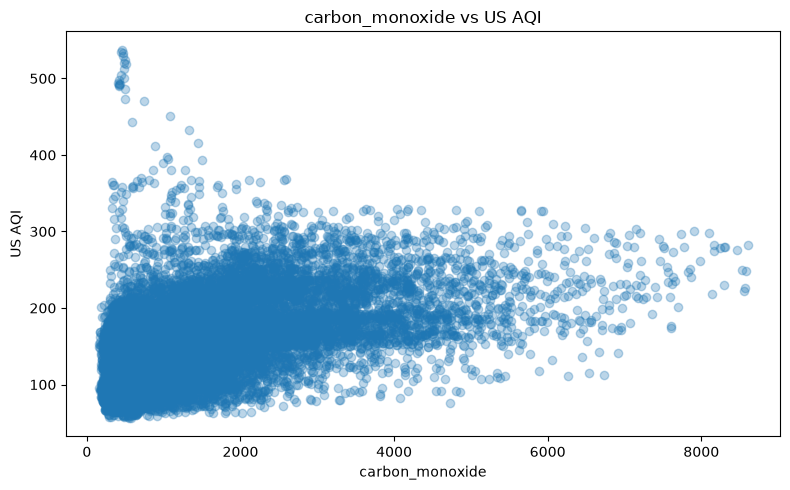

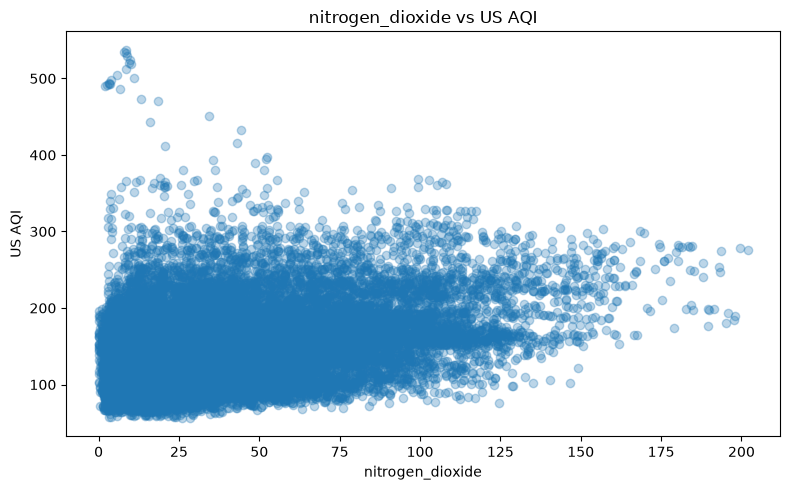

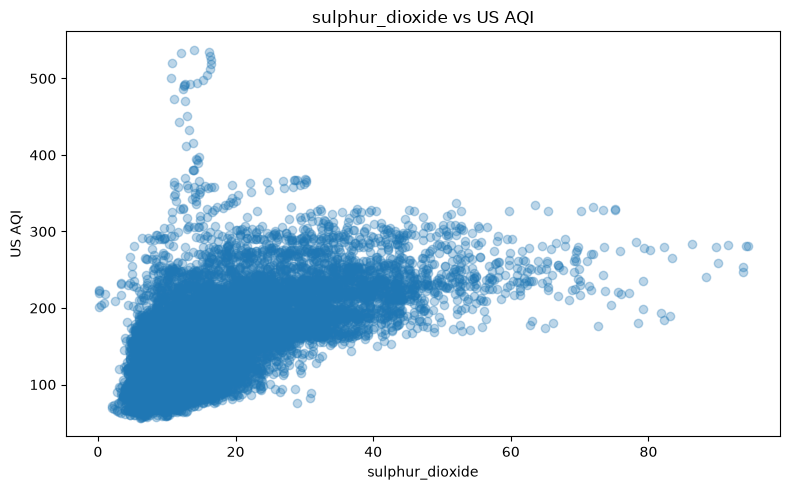

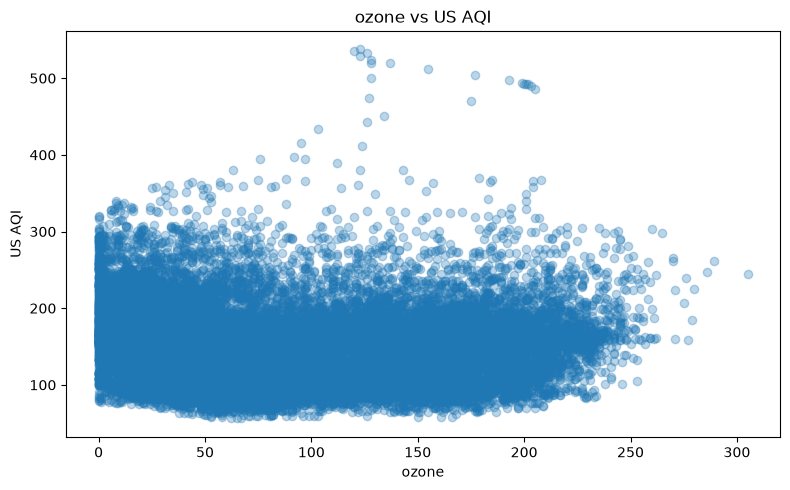

In [38]:
# ==========================================
# Pollutants vs AQI
# ==========================================

for column in pollutant_columns:

    plt.figure(figsize=(8, 5))

    plt.scatter(
        lahore_df[column],
        lahore_df["us_aqi"],
        alpha=0.3
    )

    plt.xlabel(column)
    plt.ylabel("US AQI")
    plt.title(f"{column} vs US AQI")

    plt.tight_layout()
    plt.show()

In [39]:
# ==========================================
# Correlation Matrix
# ==========================================

numeric_columns = (
    weather_columns
    + pollutant_columns
    + ["us_aqi"]
)

correlation_matrix = (
    lahore_df[numeric_columns]
    .corr()
)

display(correlation_matrix)

,temperature_2m,relative_humidity_2m,surface_pressure,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
temperature_2m,1.000000,-0.617122,-0.783168,0.008285,-0.108072,0.231686,-0.080474,-0.577205,-0.209929,-0.569112,-0.456516,-0.449476,0.577149,-0.372277
relative_humidity_2m,-0.617122,1.000000,0.234370,0.134809,0.252434,-0.190879,-0.219651,0.481885,0.237513,0.374672,0.372466,0.250338,-0.552171,0.278595
surface_pressure,-0.783168,0.234370,1.000000,-0.089637,0.004236,-0.264986,0.218694,0.455510,0.136278,0.511622,0.313321,0.505224,-0.225304,0.369270
precipitation,0.008285,0.134809,-0.089637,1.000000,0.178565,0.126432,-0.066252,-0.067540,-0.048118,-0.077804,-0.077839,-0.080510,-0.005754,-0.071342
cloud_cover,-0.108072,0.252434,0.004236,0.178565,1.000000,0.117042,-0.146026,0.060175,0.042612,-0.021164,-0.094071,-0.021124,-0.019486,0.031803
wind_speed_10m,0.231686,-0.190879,-0.264986,0.126432,0.117042,1.000000,-0.039066,-0.363997,-0.114113,-0.452413,-0.386356,-0.401821,0.145009,-0.280045
wind_direction_10m,-0.080474,-0.219651,0.218694,-0.066252,-0.146026,-0.039066,1.000000,-0.062878,-0.137794,0.059539,-0.012879,0.034905,0.055562,-0.020539
pm2_5,-0.577205,0.481885,0.455510,-0.067540,0.060175,-0.363997,-0.062878,1.000000,0.737814,0.727085,0.644332,0.762566,-0.370047,0.753438
pm10,-0.209929,0.237513,0.136278,-0.048118,0.042612,-0.114113,-0.137794,0.737814,1.000000,0.367156,0.323692,0.452515,-0.102839,0.601897
carbon_monoxide,-0.569112,0.374672,0.511622,-0.077804,-0.021164,-0.452413,0.059539,0.727085,0.367156,1.000000,0.750282,0.711921,-0.453045,0.495716


In [40]:
# ==========================================
# Correlation with AQI
# ==========================================

aqi_correlations = (
    correlation_matrix["us_aqi"]
    .sort_values(ascending=False)
)

display(aqi_correlations)

us_aqi                  1.000000
pm2_5                   0.753438
sulphur_dioxide         0.612636
pm10                    0.601897
carbon_monoxide         0.495716
surface_pressure        0.369270
nitrogen_dioxide        0.347265
relative_humidity_2m    0.278595
cloud_cover             0.031803
ozone                  -0.018944
wind_direction_10m     -0.020539
precipitation          -0.071342
wind_speed_10m         -0.280045
temperature_2m         -0.372277
Name: us_aqi, dtype: float64

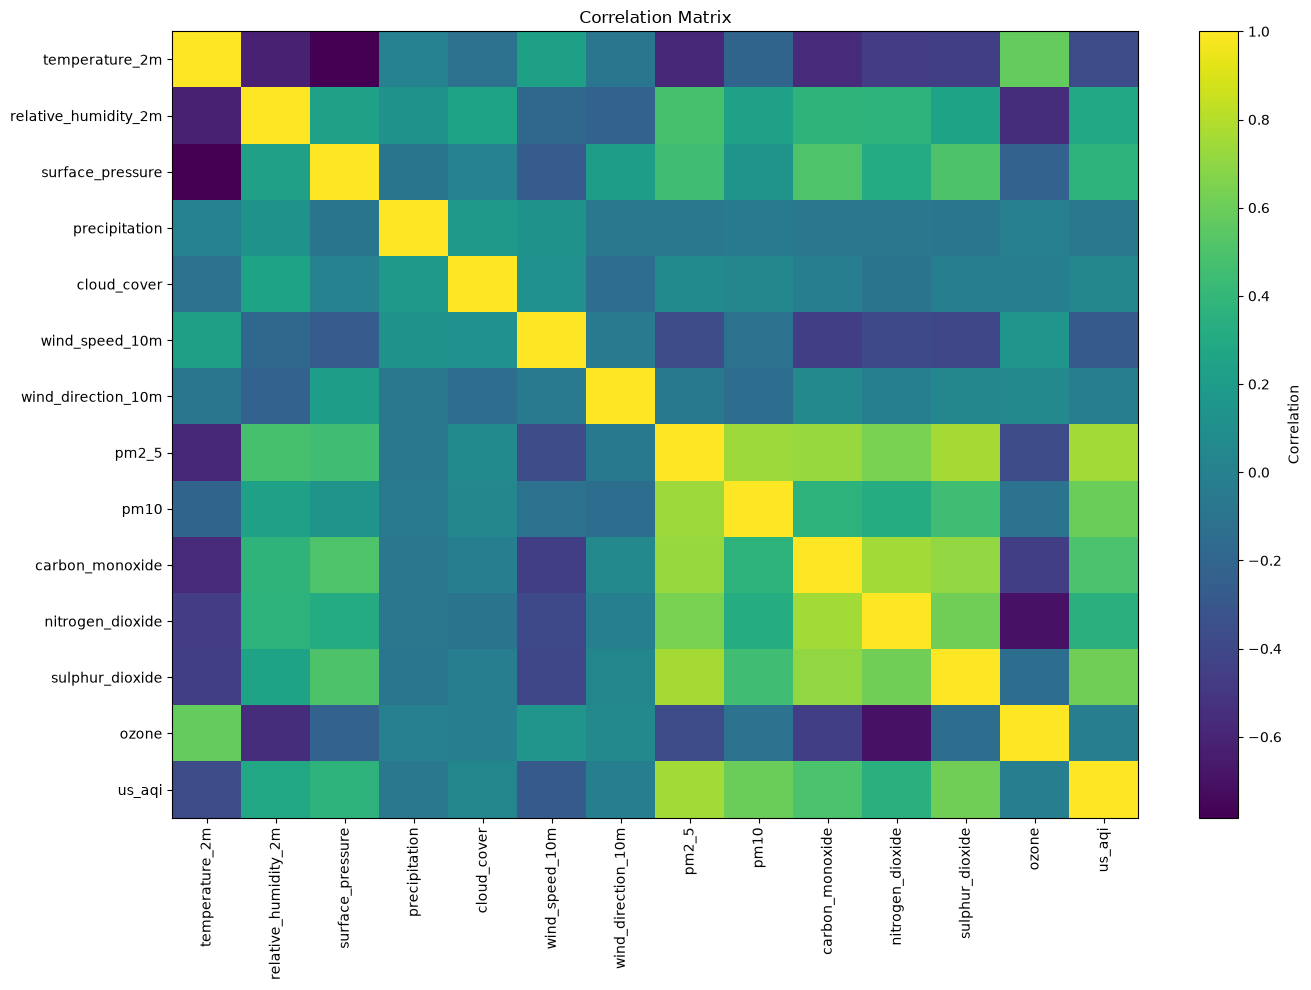

In [41]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(14, 10))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

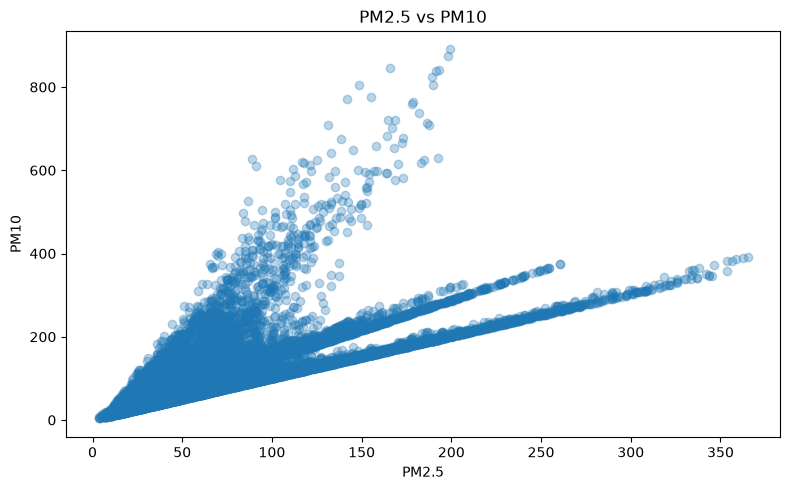

In [42]:
# ==========================================
# PM2.5 vs PM10
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    lahore_df["pm2_5"],
    lahore_df["pm10"],
    alpha=0.3
)

plt.xlabel("PM2.5")
plt.ylabel("PM10")
plt.title("PM2.5 vs PM10")

plt.tight_layout()
plt.show()

In [43]:
# ==========================================
# PM10 / PM2.5 Ratio
# ==========================================

lahore_df["pm10_pm25_ratio"] = (
    lahore_df["pm10"] /
    lahore_df["pm2_5"].replace(0, np.nan)
)

print(
    lahore_df["pm10_pm25_ratio"].describe()
)

count    22632.000000
mean         1.590581
std          0.678639
min          1.000000
25%          1.058637
50%          1.450138
75%          1.767333
max          7.060742
Name: pm10_pm25_ratio, dtype: float64


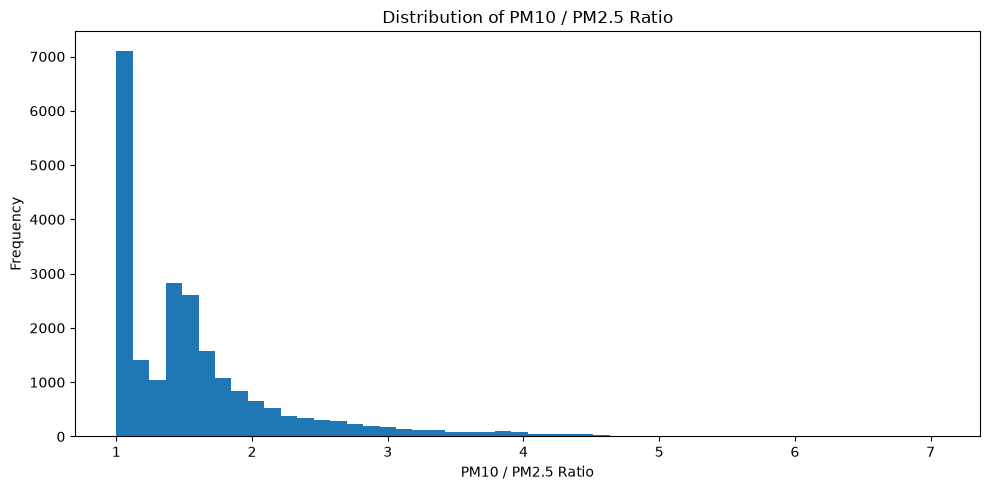

In [44]:
plt.figure(figsize=(10, 5))

plt.hist(
    lahore_df["pm10_pm25_ratio"].dropna(),
    bins=50
)

plt.xlabel("PM10 / PM2.5 Ratio")
plt.ylabel("Frequency")
plt.title("Distribution of PM10 / PM2.5 Ratio")

plt.tight_layout()
plt.show()

In [45]:
# ==========================================
# Top 20 Highest AQI Observations
# ==========================================

top_aqi = (
    lahore_df
    .sort_values("us_aqi", ascending=False)
    .head(20)
)

display(
    top_aqi[
        [
            "datetime",
            "us_aqi",
            "pm2_5",
            "pm10",
            "carbon_monoxide",
            "nitrogen_dioxide",
            "sulphur_dioxide",
            "ozone"
        ]
    ]
)

,datetime,us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
12196,2025-05-23 04:00:00,537.53754,133.2,519.7,451.0,8.4,13.9,123.0
12197,2025-05-23 05:00:00,534.97920,140.6,571.8,448.0,7.9,16.1,120.0
12195,2025-05-23 03:00:00,532.72920,148.1,601.6,466.0,8.6,12.0,126.0
12198,2025-05-23 06:00:00,528.77080,131.8,510.4,468.0,8.8,16.3,123.0
12199,2025-05-23 07:00:00,524.42500,122.9,506.6,500.0,9.9,16.5,128.0
12194,2025-05-23 02:00:00,520.15830,163.9,681.7,488.0,9.4,10.8,128.0
12200,2025-05-23 08:00:00,519.45830,110.1,466.6,514.0,10.1,16.5,137.0
12201,2025-05-23 09:00:00,512.66660,98.0,418.2,489.0,8.4,16.3,155.0
12202,2025-05-23 10:00:00,504.40417,93.1,411.6,445.0,5.8,15.9,177.0
12193,2025-05-23 01:00:00,500.28748,178.8,763.7,489.0,10.9,10.6,128.0


In [46]:
# ==========================================
# Highest AQI by Month
# ==========================================

monthly_max_aqi = (
    lahore_df
    .groupby("month")["us_aqi"]
    .max()
)

display(monthly_max_aqi)

month
1     339.20837
2     236.18335
3     208.83460
4     213.39957
5     537.53754
6     397.38020
7     364.27094
8     205.07516
9     210.24438
10    204.13531
11    368.00415
12    308.24585
Name: us_aqi, dtype: float64

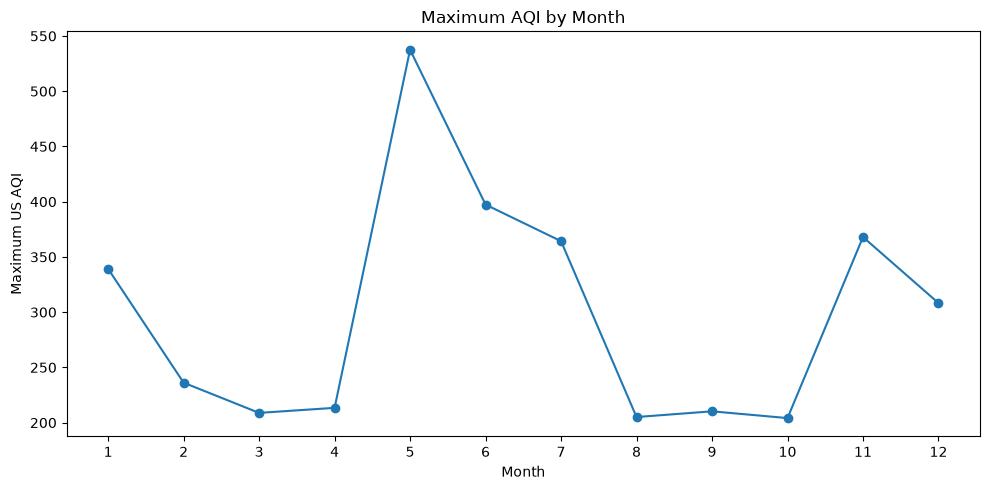

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_max_aqi.index,
    monthly_max_aqi.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Maximum US AQI")
plt.title("Maximum AQI by Month")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [48]:
# ==========================================
# High AQI Observations
# ==========================================

high_aqi_df = lahore_df[
    lahore_df["us_aqi"] >= 300
]

print(
    "Number of observations with AQI >= 300:",
    len(high_aqi_df)
)

display(
    high_aqi_df[
        [
            "datetime",
            "temperature_2m",
            "relative_humidity_2m",
            "surface_pressure",
            "precipitation",
            "cloud_cover",
            "wind_speed_10m",
            "pm2_5",
            "pm10",
            "us_aqi"
        ]
    ].head(20)
)

Number of observations with AQI >= 300: 205


,datetime,temperature_2m,relative_humidity_2m,surface_pressure,precipitation,cloud_cover,wind_speed_10m,pm2_5,pm10,us_aqi
7632,2024-11-14 00:00:00,18.15,92.416410,987.45520,0.0,54.0,2.099143,353.9,380.9,300.22916
7633,2024-11-14 01:00:00,17.60,94.764755,987.30990,0.0,76.0,0.804984,358.6,386.5,307.79587
7634,2024-11-14 02:00:00,17.15,96.879906,987.27060,0.0,40.0,3.710795,362.3,390.2,315.57916
7635,2024-11-14 03:00:00,17.20,95.353960,987.37244,0.0,8.0,4.755544,365.1,392.1,323.53333
7636,2024-11-14 04:00:00,17.15,94.445786,987.56305,0.0,0.0,5.876938,356.7,380.9,331.64580
7637,2024-11-14 05:00:00,16.95,94.136570,988.03260,0.0,1.0,5.195113,334.3,349.2,339.34998
7638,2024-11-14 06:00:00,17.45,96.886990,989.24585,0.0,1.0,6.120000,312.9,325.0,345.53754
7639,2024-11-14 07:00:00,17.65,95.672360,989.84810,0.0,1.0,7.077457,301.7,312.0,350.56250
7640,2024-11-14 08:00:00,18.95,91.014570,990.74115,0.0,45.0,7.204498,279.4,291.5,354.96667
7641,2024-11-14 09:00:00,21.00,84.834080,991.40546,0.0,69.0,5.351785,260.8,273.8,358.47920


In [49]:
high_aqi_weather = high_aqi_df[
    weather_columns
].mean()

overall_weather = lahore_df[
    weather_columns
].mean()

comparison = pd.DataFrame({
    "Overall Mean": overall_weather,
    "AQI >= 300 Mean": high_aqi_weather
})

display(comparison)

,Overall Mean,AQI >= 300 Mean
temperature_2m,24.108994,19.751707
relative_humidity_2m,62.801506,74.559912
surface_pressure,983.159531,985.652789
precipitation,0.089060,0.090732
cloud_cover,32.055320,47.317073
wind_speed_10m,6.559402,5.207791
wind_direction_10m,180.096337,122.626869


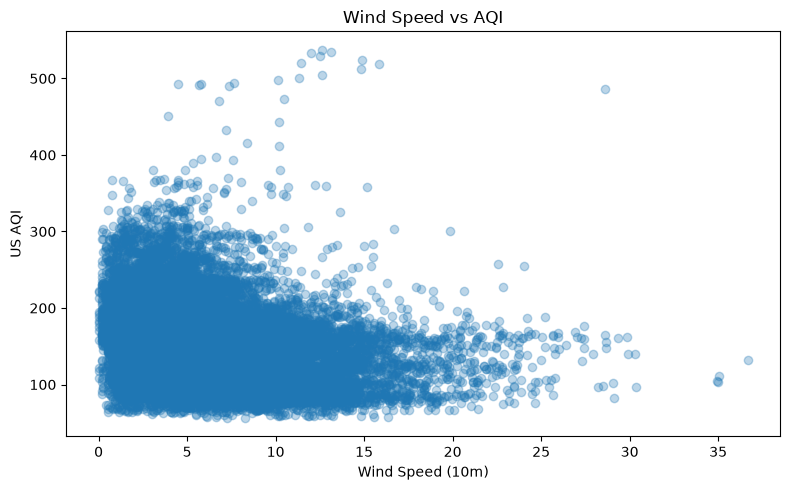

In [50]:
# ==========================================
# Wind Speed vs AQI
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    lahore_df["wind_speed_10m"],
    lahore_df["us_aqi"],
    alpha=0.3
)

plt.xlabel("Wind Speed (10m)")
plt.ylabel("US AQI")
plt.title("Wind Speed vs AQI")

plt.tight_layout()
plt.show()

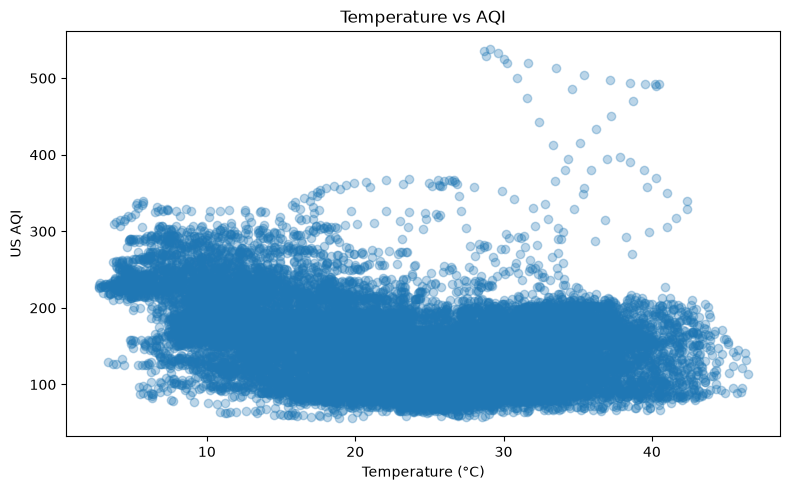

In [51]:
# ==========================================
# Temperature vs AQI
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    lahore_df["temperature_2m"],
    lahore_df["us_aqi"],
    alpha=0.3
)

plt.xlabel("Temperature (°C)")
plt.ylabel("US AQI")
plt.title("Temperature vs AQI")

plt.tight_layout()
plt.show()

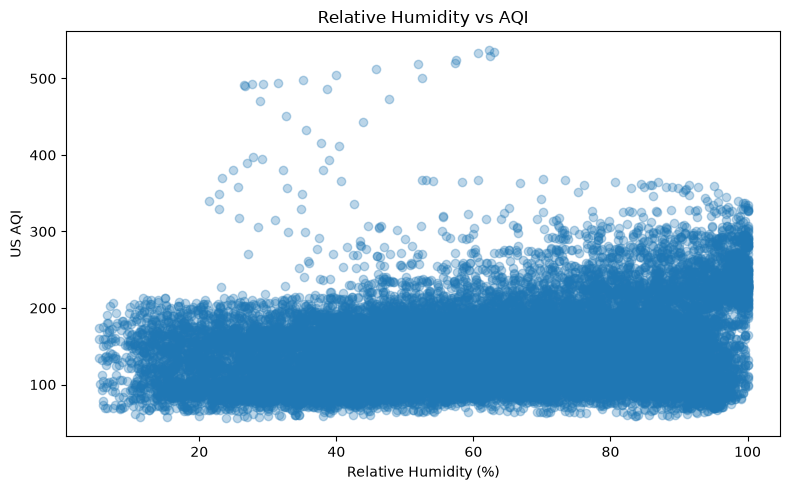

In [52]:
# ==========================================
# Humidity vs AQI
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    lahore_df["relative_humidity_2m"],
    lahore_df["us_aqi"],
    alpha=0.3
)

plt.xlabel("Relative Humidity (%)")
plt.ylabel("US AQI")
plt.title("Relative Humidity vs AQI")

plt.tight_layout()
plt.show()

In [53]:
# ==========================================
# Create Season Variable for EDA
# ==========================================

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"


lahore_df["season"] = (
    lahore_df["month"]
    .apply(get_season)
)

print(lahore_df["season"].value_counts())

season
Spring    6624
Summer    5880
Winter    5760
Autumn    4368
Name: count, dtype: int64


In [54]:
# ==========================================
# Seasonal AQI
# ==========================================

seasonal_aqi = (
    lahore_df
    .groupby("season")["us_aqi"]
    .agg(
        mean="mean",
        median="median",
        maximum="max",
        minimum="min"
    )
)

display(seasonal_aqi)

,mean,median,maximum,minimum
season,,,,
Autumn,158.867071,158.334815,368.00415,66.996860
Spring,121.439364,113.005210,537.53754,56.139935
Summer,138.795190,140.484385,397.38020,59.433960
Winter,191.942253,184.555060,339.20837,83.246860


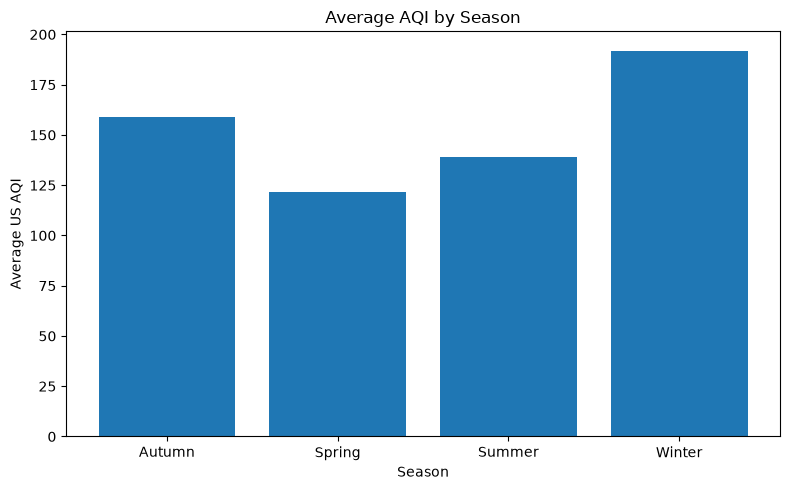

In [55]:
plt.figure(figsize=(8, 5))

plt.bar(
    seasonal_aqi.index,
    seasonal_aqi["mean"]
)

plt.xlabel("Season")
plt.ylabel("Average US AQI")
plt.title("Average AQI by Season")

plt.tight_layout()
plt.show()

## EDA Findings

### Data Quality
- The dataset contains hourly records of Lahore air quality and weather variables, providing a strong basis for time-series analysis.
- The cleaned dataset is complete, with no missing values detected in the key variables used for analysis. 
- No duplicate rows or duplicate timestamps were found, confirming the integrity of the time series.
- Hourly continuity was verified, and the record follows a consistent one-hour interval without major gaps.
- The dataset includes both meteorological and pollutant features, allowing a meaningful investigation of the drivers of AQI.

### AQI
- AQI values in Lahore were frequently elevated and often remained above acceptable health thresholds.
- The AQI distribution was highly skewed, with a concentration of observations in moderate to unhealthy ranges and a smaller number of extreme peaks.
- A few very high AQI observations indicate severe pollution episodes that materially affect air quality conditions.
- The AQI time series shows substantial variability, suggesting that pollution levels are influenced by both recurring patterns and short-lived events.
- The presence of sharp upward spikes indicates that episodic emissions and unfavorable atmospheric conditions play a major role in AQI deterioration.

### Temporal Patterns
- AQI showed a clear temporal structure, with noticeable changes across the day, month, and season.
- The highest average AQI occurred during cooler and more stagnant seasonal periods, when pollutant dispersion is weaker.
- The lowest average AQI occurred during comparatively cleaner periods when environmental conditions supported better ventilation and dilution.
- Hourly patterns suggest that AQI rises during periods associated with stronger emissions and reduced dispersion, while it tends to improve during more favorable periods.
- Seasonal analysis confirms that Lahore experiences a persistent worsening of air quality during certain times of the year, highlighting the importance of seasonal forecasting.

### Pollutants
- PM2.5 showed the strongest association with AQI and appears to be one of the dominant contributors to poor air quality conditions.
- PM10 also displayed elevated concentrations and followed a pattern similar to AQI, indicating that coarse particulate pollution is a major concern.
- Other pollutants such as carbon monoxide, nitrogen dioxide, sulfur dioxide, and ozone also contributed to the pollution burden, although their influence varied by time and condition.
- The pollutant distributions were right-skewed, with several high-concentration observations driving the extreme AQI events.
- The strong link between particulate pollutants and AQI highlights the central role of combustion and urban emissions in Lahore’s pollution profile.

### Weather Relationships
- Wind speed showed an inverse relationship with AQI, suggesting that stronger airflow helps disperse pollutants and reduces pollution concentration.
- Temperature showed a meaningful connection with AQI, indicating that thermal and atmospheric conditions influence pollutant buildup and removal.
- Relative humidity also showed a relationship with AQI, suggesting that moisture and atmospheric stability can contribute to worsening air quality.
- Weather variables appear to influence AQI indirectly by changing dispersion, accumulation, and vertical mixing conditions in the atmosphere.
- The combination of weak wind, stable conditions, and elevated pollutant concentrations is consistent with the observed severe AQI episodes.

### Extreme Events
- The highest AQI observations represent short but intense pollution episodes that significantly exceed normal conditions.
- These extreme events were associated with elevated PM2.5 and PM10 levels, confirming that particulate matter is the dominant driver of severe air quality deterioration.
- High-AQI periods were also linked to unfavorable meteorological conditions, especially low dispersion and stable atmospheric states.
- These episodes are the most critical from a public health perspective because they create the strongest risk to human exposure and respiratory stress.
- Overall, the EDA indicates that Lahore’s air quality is strongly shaped by particulate pollution, seasonal meteorology, and episodic pollution surges that can push AQI into hazardous ranges.
